# DX 704 Week 3 Project - Bandit Algorithms

<font color = 'red'> FINAL SCORE: 57/80 </font>


This week's project will give you practice with optimizing choices for bandit algorithms.
You will be given access to the bandit problem via a blackbox object, and you will investigate the bandit rewards to pick a suitable algorithm.

The full project description, a template notebook and supporting code are available on GitHub: [Project 3 Materials](https://github.com/bu-cds-dx704/dx704-project-03).


## Example Code

You may find it helpful to refer to these GitHub repositories of Jupyter notebooks for example code.

* https://github.com/bu-cds-omds/dx601-examples
* https://github.com/bu-cds-omds/dx602-examples
* https://github.com/bu-cds-omds/dx603-examples
* https://github.com/bu-cds-omds/dx704-examples

Any calculations demonstrated in code examples or videos may be found in these notebooks, and you are allowed to copy this example code in your homework answers.

## Imports

In [1]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
import random

sns.set_theme(font_scale=0.8) 
# plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.titlesize']  = 10
plt.rcParams['axes.labelsize']  = 8
plt.rcParams['lines.linewidth'] = 0.5
# plt.rcParams['lines.markersize'] = 3
plt.rcParams['axes.edgecolor']  = 'gray'
plt.rcParams['xtick.color']     = 'gray'
plt.rcParams['ytick.color'] = 'gray'
plt.rcParams['xtick.color'] = 'gray'
plt.rcParams['ytick.color'] = 'gray'
plt.rcParams['ytick.labelsize'] = 8
plt.rcParams['xtick.labelsize'] = 8

## Helper Functions

In [2]:


def select_arm(arm_rewards, arm_pull_counts, total_pulls = None, strategy = "ucb1", epsilon = 0.1, verbose = False):
    """
    Selects an arm using either UCB1 or epsilon-greedy strategy.

    Parameters:
        arm_rewards : list of float
            Cumulative rewards obtained from each arm.

        arm_pull_counts : list of int
            Number of times each arm has been pulled.

        total_pulls : int, optional
            Total number of arm pulls across all arms (required for UCB1).

        strategy : str
            Strategy to use: "ucb1" or "epsilon_greedy".

        epsilon : float
            Probability of choosing a random arm (used only in epsilon-greedy).

        verbose : bool
            If True, prints debug information.

    Returns:
        int
            Index of the selected arm.
    """
    num_arms = len(arm_rewards)

    if strategy == "ucb1":
        if total_pulls is None:
            raise ValueError("total_pulls must be provided for UCB1 strategy.")
        UCB_values = []
        for arm in range(num_arms):
            if arm_pull_counts[arm] == 0:
                UCB_values.append(float('inf'))  # Force exploration
            else:
                avg_reward  = arm_rewards[arm] / arm_pull_counts[arm]
                UCB         = avg_reward + np.sqrt(2 * np.log(total_pulls) / arm_pull_counts[arm])
                UCB_values.append(UCB)
                if verbose:
                    print(f'UCB1 - Arm: {arm}, Avg Reward: {avg_reward:.4f}, UCB: {UCB:.4f}')
        return np.argmax(UCB_values)

    elif strategy == "epsilon_greedy":
        if random.random() < epsilon:
            selected_arm = random.randint(0, num_arms - 1)
            if verbose:
                print(f"Epsilon-Greedy - Exploration: Randomly selected arm {selected_arm}")
        else:
            avg_rewards = [
                arm_rewards[i] / arm_pull_counts[i] if arm_pull_counts[i] > 0 else 0.0
                for i in range(num_arms)
            ]
            selected_arm = np.argmax(avg_rewards)
            if verbose:
                print(f"Epsilon-Greedy - Exploitation: Selected arm {selected_arm} with avg reward {avg_rewards[selected_arm]:.4f}")
        return selected_arm

    else:
        raise ValueError("Invalid strategy. Choose 'ucb1' or 'epsilon_greedy'.")


## Part 1: Pick a Bandit Algorithm

Experiment with the multi-armed bandit interface using `seed 0` to learn about the distribution of rewards and decide what kind of bandit algorithm will be appropriate.
A histogram will likely be helpful.

In [3]:
# DO NOT CHANGE

import numpy as np

class BanditProblem(object):
    def __init__(self, seed):
        self.seed = seed
        self.rng = np.random.default_rng(seed)

        self.num_arms = 3
        self.ns = self.rng.integers(low = 1, high = 10, size = self.num_arms)
        self.ps = self.rng.uniform(low = 0.2, high = 0.4, size = self.num_arms)

    def get_num_arms(self):
        return self.num_arms

    def get_reward(self, arm):
        if arm < 0 or arm >= self.num_arms:
            raise ValueError("Invalid arm")

        x = self.rng.uniform() # adds extra randomness by scaling the reward.
        x *= self.rng.binomial(self.ns[arm], self.ps[arm]) # multiplying binomial distribution by a uniform random variable, gives a random number of successes.


        return x


In [4]:
seed    = 0
bandit0 = BanditProblem(seed)

In [5]:
bandit0.get_num_arms()

3

In [6]:
# arms = [0, 1, 2]
# for arm in arms:
#     print(f"Arm {arm}: reward = {bandit0.get_reward(arm)}")

In [7]:
# YOUR CHANGES HERE

num_arms    = bandit0.get_num_arms()
num_pulls   = 1000
arms        = list(range(num_arms))

rewards = {} # dictionary to store reward lists for each arm

for arm in arms:
    rewards[arm] = []

# pull each arm 1000 times
for arm in arms:
    for _ in range(num_pulls):
        rewards[arm].append(bandit0.get_reward(arm))

# rewards

Arm 0: Mean Reward = 0.8149, Std Dev = 0.7839
Arm 1: Mean Reward = 0.5735, Std Dev = 0.6337
Arm 2: Mean Reward = 0.9262, Std Dev = 0.8481


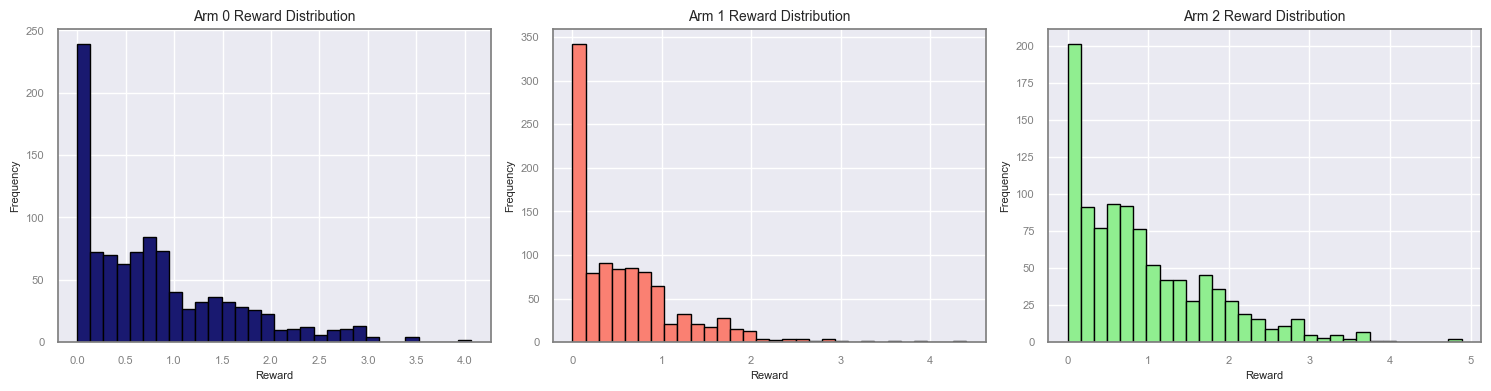

In [8]:
#  histograms for reward distributions
fig, axs    = plt.subplots(1, num_arms, figsize = (15, 4)) # 1 row, num_arms columns
colors      = ['midnightblue', 'salmon', 'lightgreen']

for arm in arms:
    axs[arm].hist(rewards[arm], bins = 30, edgecolor = 'black', color = colors[arm])
    axs[arm].set_title(f'Arm {arm} Reward Distribution')
    axs[arm].set_xlabel('Reward')
    axs[arm].set_ylabel('Frequency')
    print(f'Arm {arm}: Mean Reward = {np.mean(rewards[arm]):.4f}, Std Dev = {np.std(rewards[arm]):.4f}')

plt.tight_layout()
plt.show()



Based on your investigation, pick an appropriate bandit algorithm to implement from the algorithms covered this week.
Write a file "algorithm-choice.txt" that states your choice and gives a few sentences justifying your choice and rejecting the alternatives.
Keep your explanation concise; overly verbose responses will be penalized.

## Part 2: Implement Bandit

Based on your decision, implement an appropriate bandit algorithm and pick 1000 actions using `seed 2025002`.

In [9]:
# YOUR CHANGES HERE
seed        = 2025002
bandit2     = BanditProblem(seed)
num_arms    = bandit2.get_num_arms()
# print(f'Number of arms: {num_arms}')
num_actions = 1000
bandit_algo = "UCB1"  # "UCB1" or "Epsilon-Greedy"

# counting variables for UCB1
total_pulls     = 0
arm_pull_counts = [0] * num_arms # [0 for _ in num_arms ]
arm_rewards     = [0] * num_arms # [0 for _ in num_arms ]
history         = []

# print(arm_pull_counts)
# print(arm_rewards)

In [10]:

# --- Initial EXPLORATION - pull each arm at least once to get an initial average reward ------
for arm in arms:
    reward                  = bandit2.get_reward(arm)
    arm_pull_counts[arm]    += 1
    arm_rewards[arm]        += reward
    total_pulls             += 1
    history.append({'action': arm, 'reward': reward})

In [11]:
# --- Exploitation/Exploration loop using select_arm ---

for _ in range(num_actions - num_arms):  # already pulled each arm once
    # Select arm using bandit algorithm
    selected_arm = select_arm(
        arm_rewards,
        arm_pull_counts,
        total_pulls = total_pulls if bandit_algo == "UCB1" else None,
        strategy    = bandit_algo.lower(),  # "ucb1" or "epsilon_greedy", forcing the goddamn lowercase this took me f*cking forever to troubleshoot
        epsilon     = 0.1,
        verbose     = False
    )

    # Pull it
    reward = bandit2.get_reward(selected_arm)

    # Update counts
    arm_pull_counts[selected_arm]   += 1
    arm_rewards[selected_arm]       += reward
    total_pulls                     += 1

    # Store the history
    history.append({'action': selected_arm, 'reward': reward})


In [12]:

df_history = pd.DataFrame(history)


df_history.head(20)

,action,reward
0,0,1.575207
1,1,0.000000
2,2,0.000000
3,0,1.804006
4,0,0.432083
5,0,0.508036
6,0,0.000000
7,1,0.410877
8,2,0.389966
9,0,0.657080


In [13]:
len(df_history)

1000

Arm 0: Mean Reward = 0.5839, Std Dev = 0.6236
Arm 1: Mean Reward = 0.5135, Std Dev = 0.5624
Arm 2: Mean Reward = 0.1852, Std Dev = 0.2805


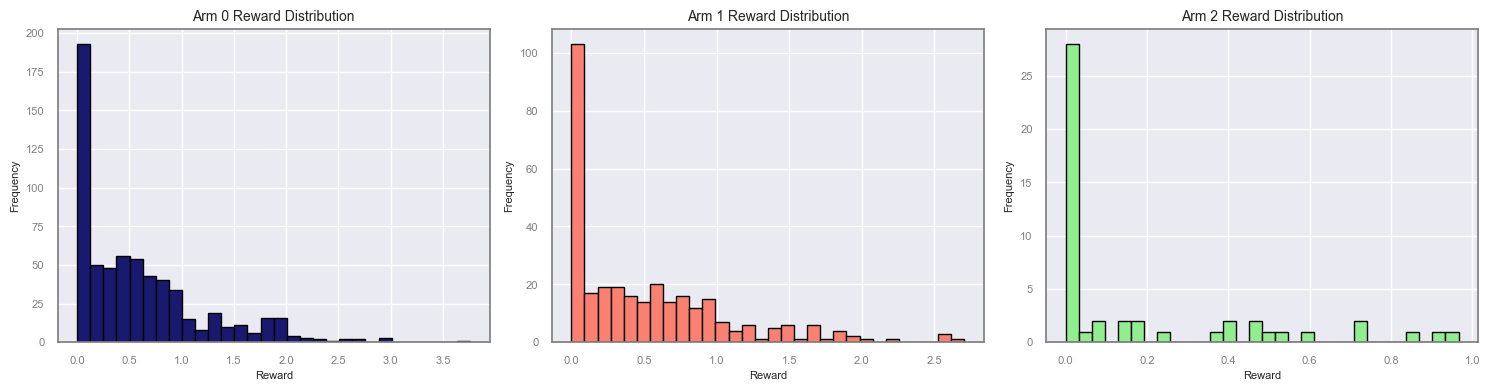

In [15]:
fig, axs    = plt.subplots(1, num_arms, figsize = (15, 4)) # 1 row, num_arms columns
colors      = ['midnightblue', 'salmon', 'lightgreen']

for action in arms:
    criteria = df_history['action'] == action

    axs[action].hist(df_history['reward'][criteria], 
                     bins = 30, edgecolor = 'black', 
                     color = colors[action])
    axs[action].set_title(f'Arm {action} Reward Distribution')
    axs[action].set_xlabel('Reward')
    axs[action].set_ylabel('Frequency')
    print(f'Arm {action}: Mean Reward = {np.mean(df_history["reward"][criteria]):.4f}, Std Dev = {np.std(df_history["reward"][criteria]):.4f}')

plt.tight_layout()
plt.show()

Write a file "history.tsv" with columns `action` and `reward` in the order that the actions were taken.

In [ ]:
# YOUR CHANGES HERE
df_history.to_csv('history.tsv', sep = '\t', index = False)

print(f"{bandit_algo} implementation, History saved to history.tsv")

UCB1 implementation, History saved to history.tsv


Submit "history.tsv" in Gradescope.

## Part 3: Action Statistics

Based on the data from part 2, estimate the <font color='plum'>expected reward for each arm</font> and write a file "actions.tsv" with the columns `action`, `min_reward`, `mean_reward`, `max_reward`.

In [ ]:
# Group  by 'action' (the arm), then calculate the statistics. 
# Gangsta way to do this rather than looping and calculating manually

actions_df = df_history.copy()
actions_df = actions_df.groupby('action')['reward'].agg(['min', 'mean', 'max'])
actions_df

,min,mean,max
action,,,
0,0.0,0.583870,3.761461
1,0.0,0.513534,2.707422
2,0.0,0.185208,0.966617


In [ ]:
# Reset the index to make 'action' a column
actions_df          = actions_df.reset_index()
actions_df.columns  = ['action', 'min_reward', 'mean_reward', 'max_reward']
actions_df

,action,min_reward,mean_reward,max_reward
0,0,0.0,0.583870,3.761461
1,1,0.0,0.513534,2.707422
2,2,0.0,0.185208,0.966617


In [ ]:
actions_df.to_csv('actions.tsv', sep='\t', index=False)

print(f"Action stats using {bandit_algo} saved to actions.tsv")

Action stats using UCB1 saved to actions.tsv


Submit "actions.tsv" in Gradescope.

## Part 4: Regret Estimates

Calculate the *expected regret* taking 1000 actions with the following strategies.

* *uniform*: Pick an arm uniformly at random.
* *just-i*: Always pick arm $i$. Do this for $i=0$ to $K-1$ where $K$ is the number of arms.
* *actual*: This should match your output in part 2.

Write your results to a file "strategies.tsv" with the columns `strategy` and `regret`.

In [ ]:
# YOUR CHANGES HERE

optimal_expected_reward = actions_df['mean_reward'].max()
num_actions             = 1000
total_optimal_reward    = num_actions * optimal_expected_reward

print(f'{bandit_algo} Optimal Expected Reward per action: {optimal_expected_reward:.4f}')
print(f'{bandit_algo} Total Optimal Reward: {total_optimal_reward:.4f}')

UCB1 Optimal Expected Reward per action: 0.5839
UCB1 Total Optimal Reward: 583.8705


### Uniform

In [ ]:
# UNIFORM strategy regret

rng             = np.random.default_rng(seed)
uniform_rewards = []

for _ in range(num_actions):
    selected_arm    = rng.integers(0, num_arms)
    reward          = bandit2.get_reward(selected_arm)
    uniform_rewards.append(reward)

uniform_regret      = total_optimal_reward - sum(uniform_rewards)
print(f'{bandit_algo} uniform_regret: {uniform_regret:.4f}')

# uniform_rewards = [bandit2.get_reward(selected_arm) for _ in range(num_actions)]


UCB1 uniform_regret: 162.9635


<font color = 'cyan'>

**The Uniform Strategy's Expected Reward**
- To "pick an arm uniformly at random" means that each of the three arms has an equal 1/3 probability of being chosen at any given time.

- The expected reward of a single pull from the uniform strategy is the **average of the expected rewards of each individual arm**. This is a property of expected values.

#### <font color='cyan'> Correct Answer

Autograder's Calculation: The expected regret for a uniform strategy is calculated using the mean reward of each arm.

1. determine the **optimal mean reward** (μ 
∗
 ), which is `0.583870` (the mean reward of arm 0, based on your own Part 3 output).

2. calculate the **expected reward of the uniform strategy**, which is the average of the mean rewards of all arms: `(0.583870 + 0.513534 + 0.185208) / 3 = 0.427537.`

3. Expected Regret taking 1000 actions: <br>
        `expected regret = (optimal total reward) - (expected total reward from the uniform strategy)`<br>
  `1000 * (0.583870 - 0.427537) = 156.333`.

Your value of `162.963472` is a valid result, but only for a single random run.

In [ ]:

# uniform_expected_reward = actions_df['mean_reward'].mean()
# uniform_regret          = num_actions * (optimal_expected_reward - uniform_expected_reward)

### Just-i

In [ ]:

# Just-i strategies regret
just_regrets = {}

for arm in range(num_arms):
    just_i_rewards = []
    for _ in range(num_actions):
        reward = bandit2.get_reward(arm)
        # print(f'arm: {arm}  reward: {reward}')
        just_i_rewards.append(reward)
    
    just_regret                 = total_optimal_reward - sum(just_i_rewards)
    just_regrets[f'just-{arm}'] = just_regret
    # print(len(just_i_rewards))
just_regrets

#  using list comprehension .... yeah it's more precise but hard to follow
# just_regrets = {
#     f'just-{arm}': total_optimal_reward - sum(bandit2.get_reward(arm) for _ in range(num_actions)) for arm in range(num_arms)
# }

{'just-0': 31.389128395290868,
 'just-1': 60.24769631641698,
 'just-2': 381.55228468452356}

#### <font color='cyan'> Correction

<font color='cyan'> 
The just-i strategy involves always picking a single arm.

Your Calculation: Similar to the uniform test, you run a new simulation for each just-i strategy (e.g., pulling arm 0, 1000 times). The rewards you get are a new random sample.

ANSWER: `expected_regret_just-i = optimal_expected_total_reward - expected_total_reward_just-i`. It's the difference between the optimal expected total reward and the expected total reward from always pulling arm i.

-  `just-0`:  `expected total reward = 1000 * (mean_reward_arm_0)`. Since Arm 0 is the optimal arm (mean_reward_arm_0 = μ 
∗
 ), the expected regret = 1000 * (0.583870 - 0.583870) = `0.0`.

- `just-1`: expected regret = 1000 * (0.583870 - 0.513534) = `70.336`.

- `just-2`: expected regret = 1000 * (0.583870 - 0.185208) = `398.662`.

Your just-0 regret value is 31.389128, which is the difference between the optimal expected total reward and the actual total reward from a single run of pulling arm 0, not the expected regret (which is zero).

### Actual

In [ ]:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    # ACTUAL UCB1 strategy Regret
total_actual_reward     = df_history['reward'].sum()
actual_regret           = total_optimal_reward - total_actual_reward

print(f'total_actual_reward: {total_actual_reward:.4f}; actual_regret: {actual_regret:.4f}')

## just-0
expected_regret_just_0 = num_actions * (optimal_expected_reward - actions_df['mean_reward'][0])
print(f'just_0: {expected_regret_just_0:.4f}')

# just-1
expected_regret_just_1 = num_actions * (optimal_expected_reward - actions_df['mean_reward'][1])
print(f'just_1: {expected_regret_just_1:.4f}')

# just-2
expected_regret_just_2 = num_actions * (optimal_expected_reward - actions_df['mean_reward'][2])
print(f'just_2: {expected_regret_just_2:.4f}')

total_actual_reward: 542.2505; actual_regret: 41.6200
just_0: 0.0000
just_1: 70.3362
just_2: 398.6624


-------------------------

In [ ]:
strategies              = ['uniform'] + list(just_regrets.keys()) + ['actual']
regrets                 = [uniform_regret] + list(just_regrets.values()) + [actual_regret]
# print(f'Strategies: {strategies}')
# print(f'Regrets: {regrets}')
strategies_df           = pd.DataFrame({'strategy': strategies, 'regret': regrets})
strategies_df

,strategy,regret
0,uniform,162.963472
1,just-0,31.389128
2,just-1,60.247696
3,just-2,381.552285
4,actual,41.620018


In [ ]:
strategies_df.to_csv('strategies.tsv', sep='\t', index = False)

Submit "strategies.tsv" in Gradescope.

## Part 5: Acknowledgments

Make a file `"acknowledgments.txt"` documenting any outside sources or help on this project.
If you discussed this assignment with anyone, please acknowledge them here.
If you used any libraries not mentioned in this module's content, please list them with a brief explanation what you used them for.
If you used any generative AI tools, please add links to your transcripts below, and any other information that you feel is necessary to comply with the generative AI policy.
If no acknowledgements are appropriate, just write none in the file.


Submit "acknowledgments.txt" in Gradescope.

## Part 6: Code

Please submit a Jupyter notebook that can reproduce all your calculations and recreate the previously submitted files.

Submit "project.ipynb" in Gradescope.

--------------------------

In [ ]:
# YOUR CHANGES HERE

# for arm in range(num_arms):

#     arm_data    = df_history[df_history['action'] == arm]['reward']
#     action_dict = {
#         'arm': arm,
#         'min_reward': arm_data.min(),
#         'mean_reward': arm_data.mean(),
#         'max_reward': arm_data.max()
#     }
#     action_stats.append(action_dict)

# actions_df = pd.DataFrame(action_stats)
# actions_df

In [ ]:

# # --- Initial EXPLORATION phase ---
# # pull each arm at least once to get an initial average reward
# for arm in arms:
#     reward                  = bandit2.get_reward(arm)
#     arm_pull_counts[arm]    += 1
#     arm_rewards[arm]        += reward
#     total_pulls             += 1
#     history.append({'action': arm, 'reward': reward})

# # ---  Exploitation/Exploration loop ---
# for t in range(num_actions - num_arms):
#     UCB_values = []

#     if arm_pull_counts[arm] == 0:
#         UCB = float('inf')  # Force exploration
#     else:
#         for arm in range(num_arms):
#             # Calculate the UCB value for each arm
#             avg_reward  = arm_rewards[arm] / arm_pull_counts[arm]
#             UCB         = avg_reward + np.sqrt(2 * np.log(total_pulls) / arm_pull_counts[arm])
#             UCB_values.append(UCB)
#             print(f'Arm: {arm}, Avg Reward: {avg_reward:.4f}, UCB: {UCB:.4f}')
    
#     # Choose arm with highest UCB value
#     best_arm = np.argmax(UCB_values)
    
#     # Pull selected arm and update counts
#     reward                              = bandit2.get_reward(best_arm)
#     arm_pull_counts[best_arm]           += 1
#     arm_rewards[best_arm]               += reward
#     total_pulls                         += 1
#     history.append({'action': best_arm, 'reward': reward})

# df_history = pd.DataFrame(history)
# df_history.tail(20)

In [ ]:
# # ---  UC1 Exploitation/Exploration loop ---

# for _ in range(num_actions - num_arms):  # already pulled each arm once
#     # Select arm using bandit algorithm
#     if bandit_algo == "UCB1":
#         selected_arm = ucb1_select_arm(arm_rewards, 
#                                     arm_pull_counts, 
#                                     total_pulls, 
#                                     verbose = False
#                                     )
#     else:
#         selected_arm = epsilon_greedy_select_arm(arm_rewards, 
#                                        arm_pull_counts, 
#                                        epsilon = 0.1,
#                                        verbose = False
#                                        )


#     # Pull it
#     reward       = bandit2.get_reward(selected_arm)

#     # Update counts
#     arm_pull_counts[selected_arm] += 1
#     arm_rewards[selected_arm]     += reward
#     total_pulls                   += 1

#     # store the history
#     history.append({'action': selected_arm, 'reward': reward})


In [ ]:
# def ucb1_select_arm(arm_rewards, arm_pull_counts, total_pulls, verbose = False):
    
#     """
#     Selects the arm with the highest Upper Confidence Bound (UCB1) value.

#     Implements the UCB1 algorithm for multi-armed bandit problems.
#     Calculates the UCB value for each arm based on its average reward and
#     the number of times it has been pulled, encouraging exploration of less
#     frequently pulled arms and exploitation of arms with higher average rewards.

#     Parameters:
        
#         arm_rewards : list of float
#             Cumulative rewards obtained from each arm.

#         arm_pull_counts : list of int
#             Number of times each arm has been pulled.
            
#         total_pulls : int
#             Total number of arm pulls across all arms.

#     Returns:
        
#             int
#                 Index of the arm with the highest UCB1 value.
#     """

#     UCB_values = []
    
#     for arm in range(len(arm_rewards)):
#         if arm_pull_counts[arm] == 0:
#             UCB_values.append(float('inf')) # Force exploration
#         else:
#             avg_reward  = arm_rewards[arm] / arm_pull_counts[arm]
#             UCB         = avg_reward + np.sqrt(2 * np.log(total_pulls) / arm_pull_counts[arm])
#             UCB_values.append(UCB)
#             if verbose:
#                 print(f'Arm: {arm}, Avg Reward: {avg_reward:.4f}, UCB: {UCB:.4f}')

#     return np.argmax(UCB_values)


In [ ]:


# def epsilon_greedy_select_arm(arm_rewards, arm_pull_counts, epsilon=0.1, verbose=False):
#     """
#     Selects an arm using the epsilon-greedy strategy.

#     With probability epsilon, selects a random arm (exploration).
#     With probability 1 - epsilon, selects the arm with the highest average reward (exploitation).

#     Parameters:
#         arm_rewards : list of float
#             Cumulative rewards obtained from each arm.

#         arm_pull_counts : list of int
#             Number of times each arm has been pulled.

#         epsilon : float
#             Probability of choosing a random arm (exploration).

#     Returns:
#         int
#             Index of the selected arm.
#     """

#     num_arms = len(arm_rewards)

#     if random.random() < epsilon:
#         selected_arm = random.randint(0, num_arms - 1)
#         if verbose:
#             print(f"Exploration: Randomly selected arm {selected_arm}")
#     else:
#         avg_rewards = [
#             arm_rewards[i] / arm_pull_counts[i] if arm_pull_counts[i] > 0 else 0.0
#             for i in range(num_arms)
#         ]
#         selected_arm = np.argmax(avg_rewards)
#         if verbose:
#             print(f"Exploitation: Selected arm {selected_arm} with avg reward {avg_rewards[selected_arm]:.4f}")

#     return selected_arm


from Microsoft Copilot......</br>


`Regret` =  
- key performance measure in sequential decision-making problems, like the multi-armed bandit. 
-  quantifies the difference between the maximum possible total reward and the reward actually received by an algorithm or strategy.

$Regret = (\text{Optimal Cumulative Reward}) - (\text{Actual Cumulative Reward})$

This can be broken down further:

$Regret = (n \times \mu^*) - \sum_{t=1}^{n} X_{I_t,t}$

* $n$ is the number of actions taken.
* $\mu^*$ is the mean reward of the best possible arm.
* $X_{I_t,t}$ is the reward received at time step $t$ for the arm $I_t$ chosen by the algorithm.

- lower regret value indicates better performance b/c the algorithm's choices led to a total reward closer to the theoretical maximum.
- The goal of a good multi-armed bandit algorithm: <u>minimize its cumulative regret over time</u>.

